#Analisis Kinerja Penjualan
<pre>
Ketua   : Rajif Aidil Putra Afina - 245150207111072
Anggota : Christiano Alfonsius Purba - 245150200111055
          Luthfi Pratama Sahni - 245150200111058
          Damar Tyaga Wistara - 245150200111060

##Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from itertools import combinations

##1. Data Preparation

In [ ]:
! wget https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv

--2026-05-19 08:18:47--  https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4286 (4.2K) [text/plain]
Saving to: ‘Mall_Customers.csv’

Mall_Customers.csv  100%[===================>]   4.19K  --.-KB/s    in 0s      

2026-05-19 08:18:47 (54.9 MB/s) - ‘Mall_Customers.csv’ saved [4286/4286]



In [ ]:
df = pd.read_csv('Mall_Customers.csv')

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


##2. Preprocessing Data

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


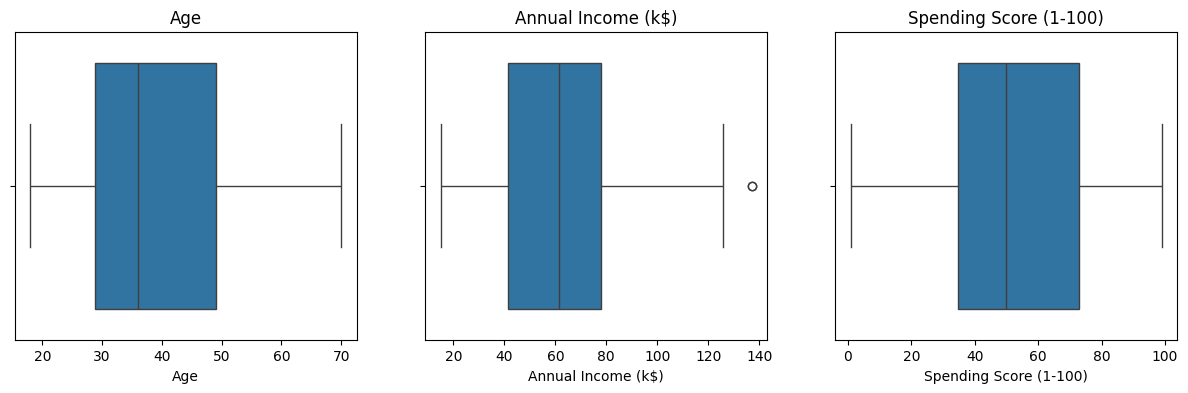

In [ ]:
numeric_cols = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

plt.figure(figsize=(15,4))

for i, col in enumerate(numeric_cols):

    plt.subplot(1,3,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.show()

In [ ]:
def remove_outlier_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[
        (data[column] >= lower) &
        (data[column] <= upper)
    ]

In [ ]:
for col in numeric_cols:

    df = remove_outlier_iqr(df, col)

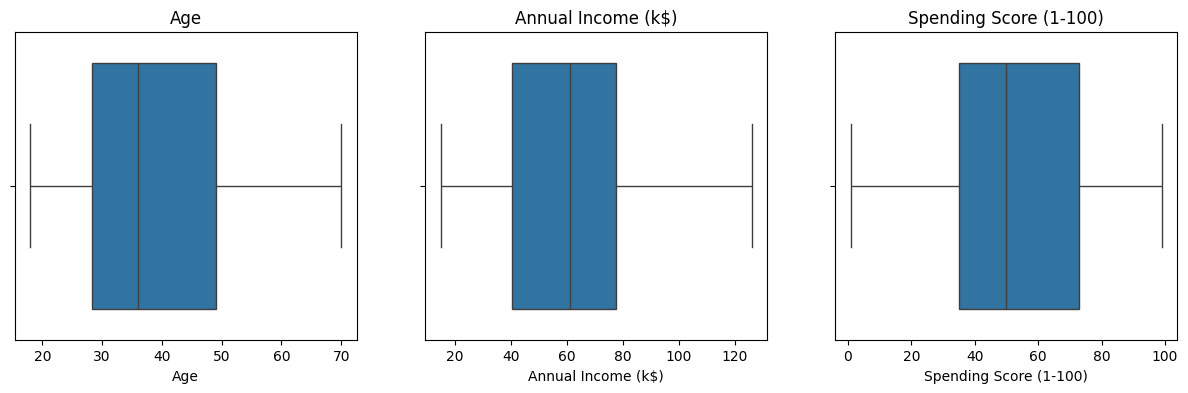

In [ ]:
numeric_cols = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

plt.figure(figsize=(15,4))

for i, col in enumerate(numeric_cols):

    plt.subplot(1,3,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.show()

##3. Exploratory Data Analysis (EDA)

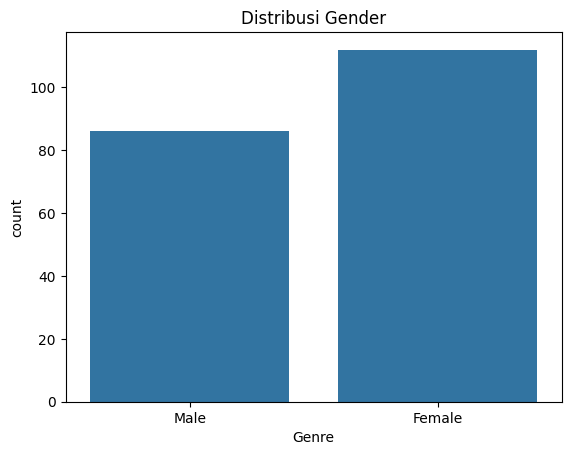

In [ ]:
sns.countplot(x='Genre', data=df)
plt.title("Distribusi Gender")
plt.show()

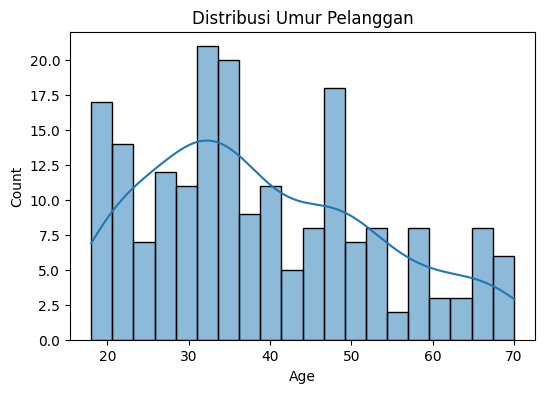

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Distribusi Umur Pelanggan')
plt.show()

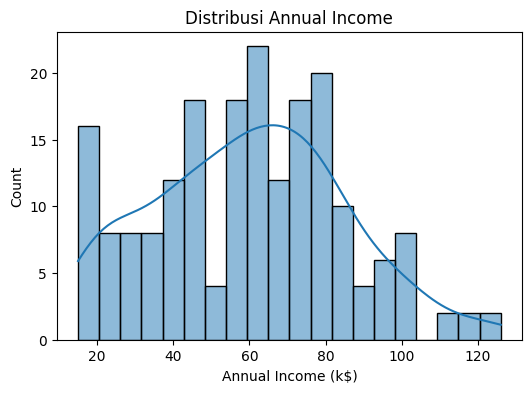

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title('Distribusi Annual Income')
plt.show()

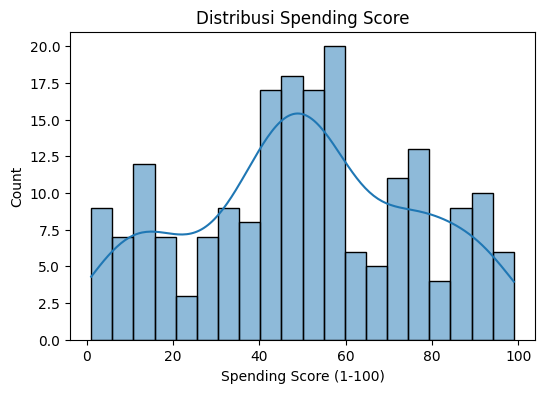

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title('Distribusi Spending Score')
plt.show()

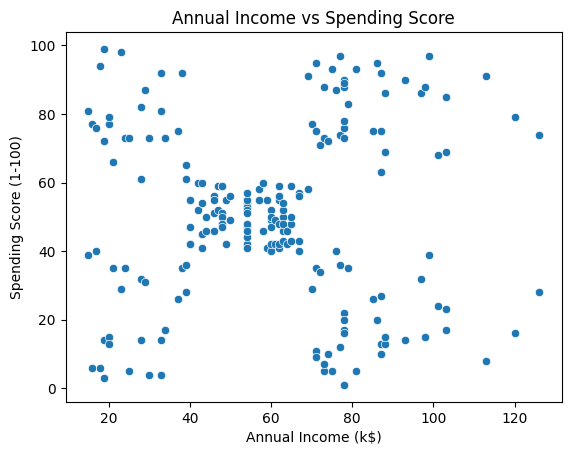

In [ ]:
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title('Annual Income vs Spending Score')
plt.show()

##4. Normalisasi Data

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
def minmax(df_input):
  return (df_input - df_input.min()) / (df_input.max() - df_input.min())

In [ ]:
df_norm = minmax(X)

##5. Penentuan Cluster Optimal

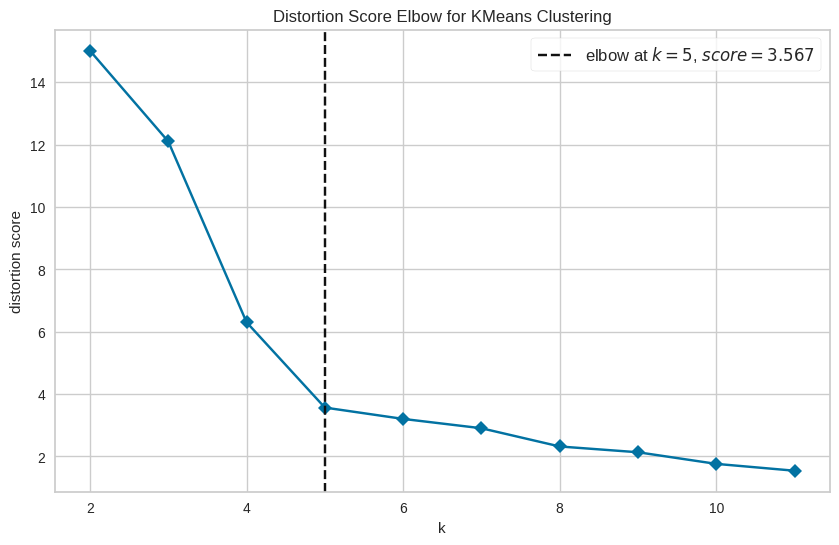

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,12), timings=False)

plt.figure(figsize=(10, 6))
visualizer.fit(df_norm)
visualizer.show()

##6. K-Means Clustering

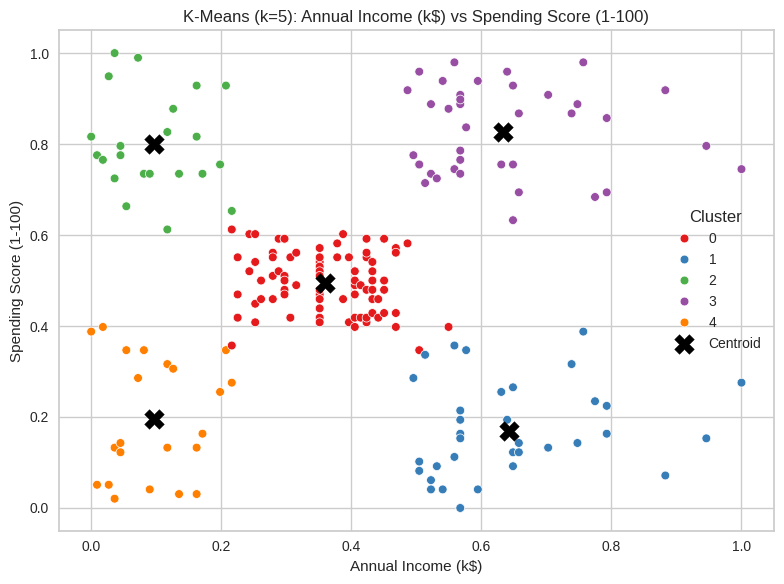

In [ ]:
cols = df_norm.columns

for comb in combinations(cols, 2):
    subset = df_norm[list(comb)]

    kmeans = KMeans(n_clusters=5, random_state=42)
    labels = kmeans.fit_predict(subset)

    centroids = kmeans.cluster_centers_

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        x=subset[comb[0]],
        y=subset[comb[1]],
        hue=labels,
        palette='Set1',
        s=40
    )

    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        c='black',
        marker='X',
        s=200,
        label='Centroid'
    )

    plt.title(f"K-Means (k=5): {comb[0]} vs {comb[1]}")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

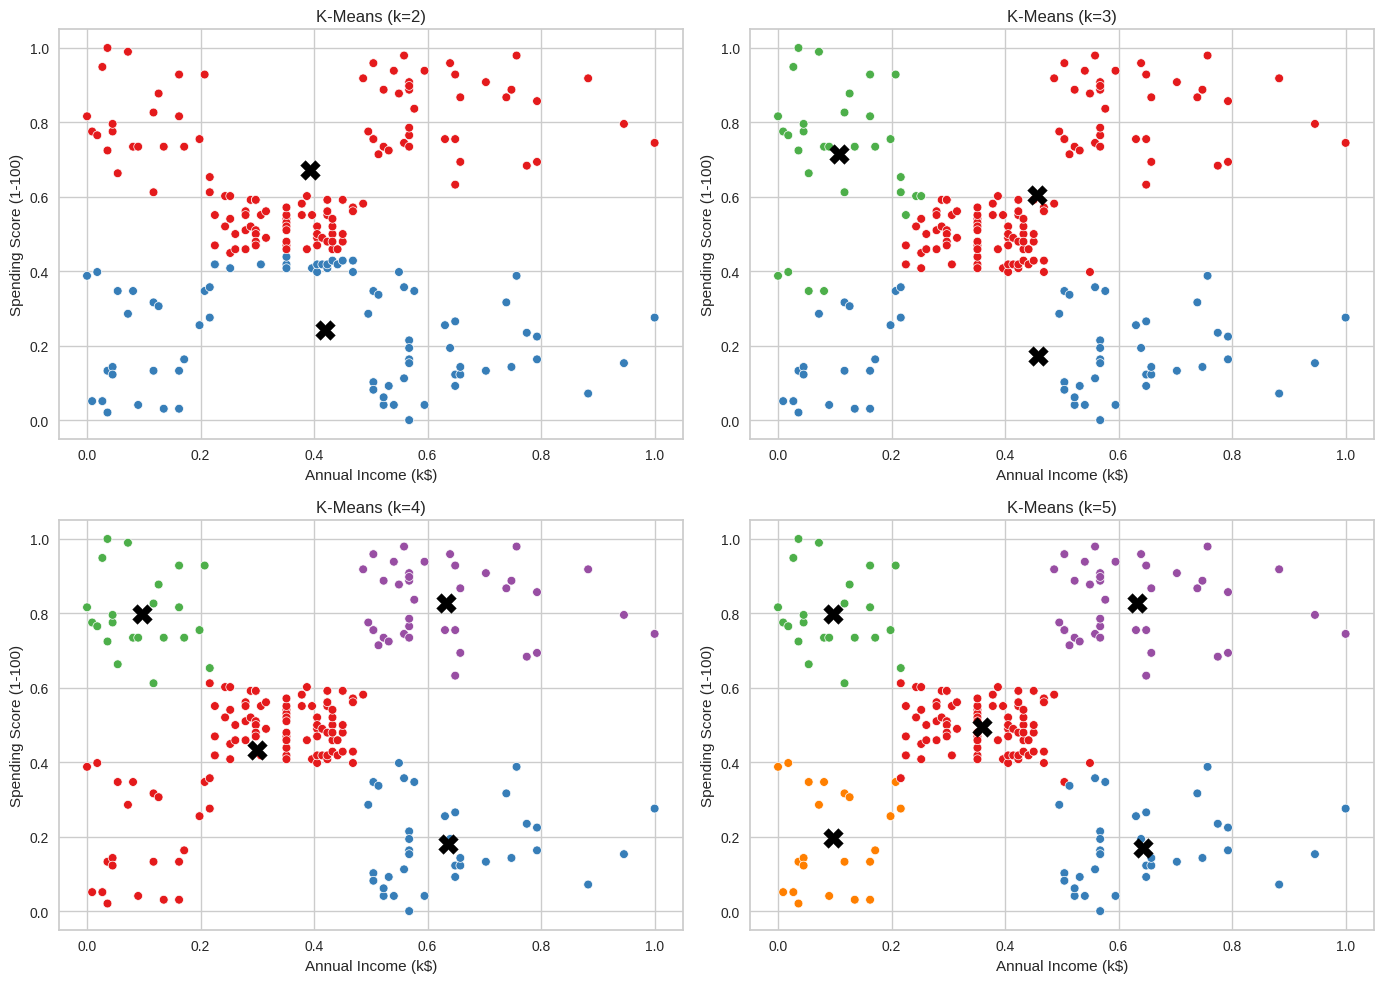

In [ ]:
k_values = [2, 3, 4, 5]

cols = df_norm.columns
comb = list(combinations(cols, 2))[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, k in enumerate(k_values):

    subset = df_norm[list(comb)]

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(subset)
    centroids = kmeans.cluster_centers_

    sns.scatterplot(
        x=subset[comb[0]],
        y=subset[comb[1]],
        hue=labels,
        palette='Set1',
        ax=axes[i],
        s=40,
        legend=False
    )

    axes[i].scatter(
        centroids[:, 0],
        centroids[:, 1],
        c='black',
        marker='X',
        s=200
    )

    axes[i].set_title(f"K-Means (k={k})")
    axes[i].set_xlabel(comb[0])
    axes[i].set_ylabel(comb[1])

plt.tight_layout()
plt.show()

##7. DBSCAN Clustering

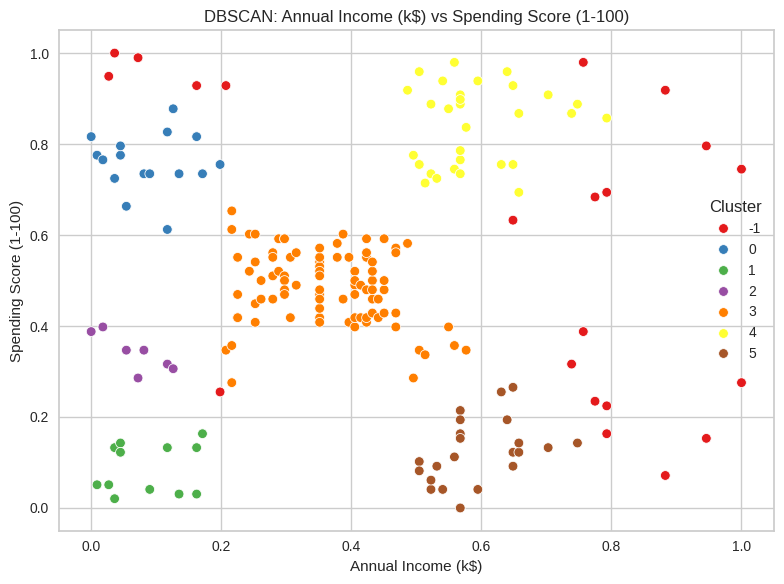

In [ ]:
cols = df_norm.columns

for comb in combinations(cols, 2):
    subset = df_norm[list(comb)]

    dbscan = DBSCAN(eps=0.085, min_samples=5)
    labels = dbscan.fit_predict(subset)

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        x=subset[comb[0]],
        y=subset[comb[1]],
        hue=labels,
        palette='Set1'
    )

    plt.title(f"DBSCAN: {comb[0]} vs {comb[1]}")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

Pada beberapa nilai eps, DBSCAN tidak mampu membentuk cluster yang optimal karena parameter terlalu sensitif terhadap kepadatan data. Hal ini menunjukkan bahwa DBSCAN kurang stabil pada dataset Mall Customers dibandingkan K-Means.

##8. Evaluasi

In [ ]:
for k in [2, 3, 4, 5]:

    subset = df_norm[list(comb)]

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(subset)

    sil = silhouette_score(subset, labels)
    cal = calinski_harabasz_score(subset, labels)
    dav = davies_bouldin_score(subset, labels)

    print(f"K = {k}")
    print(f"Silhouette Score       : {sil:.4f}")
    print(f"Calinski-Harabasz Score: {cal:.4f}")
    print(f"Davies-Bouldin Score   : {dav:.4f}")

K = 2
Silhouette Score       : 0.3318
Calinski-Harabasz Score: 114.4173
Davies-Bouldin Score   : 1.1889
K = 3
Silhouette Score       : 0.3458
Calinski-Harabasz Score: 94.0613
Davies-Bouldin Score   : 1.0747
K = 4
Silhouette Score       : 0.4991
Calinski-Harabasz Score: 179.3079
Davies-Bouldin Score   : 0.6931
K = 5
Silhouette Score       : 0.5647
Calinski-Harabasz Score: 273.4603
Davies-Bouldin Score   : 0.5595


##9. Analisis Hasil

<pre>
1. Cluster 0 (Merah)

Posisi:

* Income menengah
* Spending menengah

Karakteristik:

* Pelanggan normal/stabil
* Tidak terlalu hemat
* Tidak terlalu konsumtif

Analisis: Cluster ini kemungkinan merupakan mayoritas pelanggan biasa yang memiliki pola belanja cukup stabil.

Strategi bisnis:
* Promo umum
* Membership reguler
* Diskon musiman

2. Cluster 1 (Biru)

Posisi:

* Income tinggi
* Spending rendah

Karakteristik:
* Memiliki kemampuan membeli tinggi,
* Tetapi jarang berbelanja.

Analisis: Cluster ini merupakan pelanggan potensial yang belum dimaksimalkan oleh mall.

Strategi bisnis:

* Personalized marketing
* Voucher khusus
* Rekomendasi produk premium

3. Cluster 2 (Hijau)

Posisi:

* Income rendah
* Spending tinggi

Karakteristik:

* Suka berbelanja walaupun income rendah
* Impulsive buyer

Analisis: Pelanggan pada cluster ini cenderung konsumtif meskipun pendapatannya tidak tinggi.

Strategi bisnis:

* Promo bundling
* Cashback
* Diskon menarik

4. Cluster 3 (Ungu)

Posisi:

* Income tinggi
* Spending tinggi

Karakteristik:

* Pelanggan premium
* Loyal customer
* Daya beli tinggi

Analisis: Ini adalah pelanggan paling menguntungkan karena memiliki kemampuan membeli tinggi dan aktif berbelanja.

Strategi bisnis:

* VIP membership
* Promo eksklusif
* Reward loyalitas

5. Cluster 4 (Oranye)

Posisi:

* Income rendah
* Spending rendah

Karakteristik:

* Pelanggan pasif
* Daya beli rendah

Analisis: Cluster ini adalah pelanggan dengan aktivitas belanja paling rendah.

Strategi bisnis:

* Promo harga murah
* Diskon besar
* Produk ekonomis

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
)

centroids['Cluster'] = range(5)

income_mean = centroids['Annual Income (k$)'].mean()
spending_mean = centroids['Spending Score (1-100)'].mean()

centroids['Distance_To_Center'] = np.sqrt(
    (centroids['Annual Income (k$)'] - income_mean)**2 +
    (centroids['Spending Score (1-100)'] - spending_mean)**2
)

average_cluster = centroids[
    'Distance_To_Center'
].idxmin()

cluster_names = {}

for i, row in centroids.iterrows():

    cluster_id = row['Cluster']
    income = row['Annual Income (k$)']
    spending = row['Spending Score (1-100)']

    if cluster_id == average_cluster:
        cluster_names[cluster_id] = 'Average Customer'

    elif income > income_mean and spending > spending_mean:
        cluster_names[cluster_id] = 'Loyal Customer'

    elif income > income_mean and spending < spending_mean:
        cluster_names[cluster_id] = 'Potential Customer'

    elif income < income_mean and spending > spending_mean:
        cluster_names[cluster_id] = 'Impulsive Customer'

    elif income < income_mean and spending < spending_mean:
        cluster_names[cluster_id] = 'Passive Customer'

df['Cluster Name'] = df['Cluster'].map(cluster_names)

In [ ]:
cluster_number = {
    'Average Customer': 0,
    'Loyal Customer': 1,
    'Potential Customer': 2,
    'Impulsive Customer': 3,
    'Passive Customer': 4
}

df['Cluster'] = df[
    'Cluster Name'
].map(cluster_number)

/tmp/ipykernel_710/3471934111.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


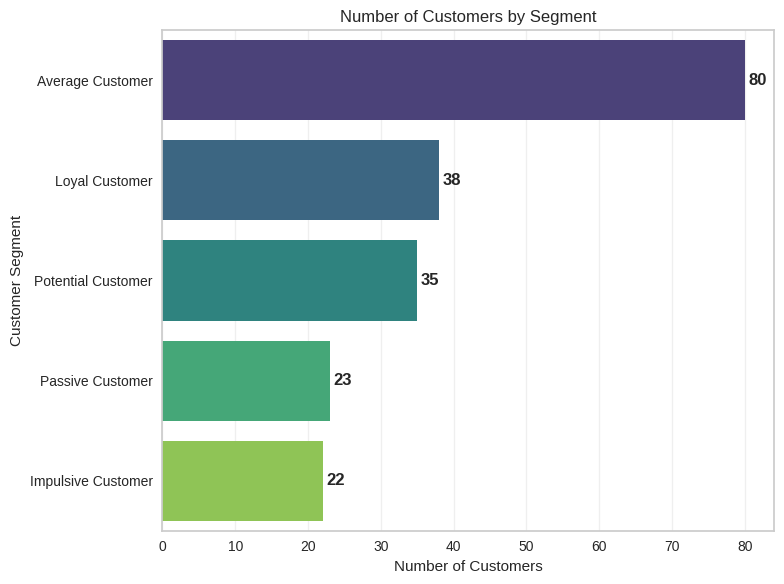

In [ ]:
cluster_count = (
    df['Cluster Name']
    .value_counts()
)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=cluster_count.values,
    y=cluster_count.index,
    palette='viridis'
)

plt.title('Number of Customers by Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')

plt.grid(axis='x', alpha=0.3)

for index, value in enumerate(cluster_count.values):
    plt.text(
        value + 0.5,
        index,
        str(value),
        va='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df['Cluster'] = df['Cluster'].values
df['Cluster Name'] = df['Cluster Name'].values

df.to_csv('Mall_Customers_Segmented.csv', index=False)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster Name
0,1,Male,19,15,39,4,Passive Customer
1,2,Male,21,15,81,3,Impulsive Customer
2,3,Female,20,16,6,4,Passive Customer
3,4,Female,23,16,77,3,Impulsive Customer
4,5,Female,31,17,40,4,Passive Customer
